# 📊 Ajuste do Modelo Multivariado VAR e Fronteiras Analíticas de Estresse

Esta seção implementa e documenta a parametrização do modelo estatístico de **Vetores Autorregressivos (VAR)** e a construção de indicadores ponderados de inflação.

## 📝 Componentes do Modelo

### 1. InflationIndexBuilder
Centraliza a composição linear dos choques de inflação. Consolida as variáveis `IPCA` e `IGP-M` com base em pesos específicos para refletir fielmente a exposição da firma aos índices de preços de mercado.

### 2. MacroTimeSeriesFitter
Estrutura um estimador multivariado onde cada variável macroeconómica é modelada como uma função linear dos seus próprios *lags* (defasagens) passados e dos *lags* das outras variáveis do sistema:

$$Y_t = c + A_1 Y_{t-1} + A_2 Y_{t-2} + \dots + A_p Y_{t-p} + u_t$$

Onde:
* $Y_t$ é o vetor de variáveis endógenas: `['selic', 'ipca', 'igpm', 'desemprego']`.
* $A_i$ representam as matrizes de coeficientes estimados automaticamente por Mínimos Quadrados Ordinários (MQO).
*A seleção da ordem ótima de defasagem ($p$) é determinada de forma endógena através da minimização do **Critério de Informação de Akaike (AIC)**.*

---

## 🔬 Projeção Analítica de Limites (Forecast Interval)

O método `.forecast_interval()` avalia a propagação do erro quadrático médio de previsão (MSE) ao longo do tempo. O modelo calcula analiticamente os limites assintóticos de confiança dado um nível de significância $\alpha$:

$$\hat{Y}_{T+h \mid T} \pm z_{\alpha/2} \times \sqrt{\text{MSE}(h)}$$

Esta abordagem permite extrair o **"Pior Cenário Plausível"** sem depender de simulações numéricas aleatórias, mapeando cenários onde a taxa SELIC e os índices de inflação divergem em direção às caudas superiores ou inferiores da distribuição teórica.

In [ ]:
import sys
import os

raiz_projeto = os.path.abspath(os.path.join(os.getcwd(), ".."))
if raiz_projeto not in sys.path:
    sys.path.append(raiz_projeto)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.models import MacroPredictorEngine, PredictorConfig
from src.models import IndexFactory
from src.simulation.monte_carlo import MacroMonteCarloSimulator

# Configurações visuais para os plots das bandas de estresse
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

import warnings
from statsmodels.tools.sm_exceptions import ValueWarning
warnings.simplefilter("ignore", category=ValueWarning)

import shutil
from statsmodels.tsa.api import VAR
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller


In [ ]:
caminho_csv = "../data/dataset_macro.csv"
df_completo = IndexFactory.ler_matriz_unificada(caminho_csv)

df_analise = df_completo[df_completo.index >= '1994-08-01'].copy()

df_analise_corrigido = df_analise.copy()

colunas_brutas = list(df_analise_corrigido.columns)
coluna_ipca = [c for c in colunas_brutas if "IPCA" in c or "433" in c][0]
coluna_igpm = [c for c in colunas_brutas if "IGP-M" in c or "200045" in c][0]
coluna_selic = [c for c in colunas_brutas if "Selic" in c or "4390" in c][0]

# --- TRATAMENTO CRUCIAL DO IGP-M ---
# Transforma o número-índice acumulado (ex: 100 -> 500) em variação percentual mensal (taxa %)
df_analise_corrigido[coluna_igpm] = pd.to_numeric(df_analise_corrigido[coluna_igpm], errors='coerce').pct_change() * 100

df_analise_corrigido[coluna_ipca] = pd.to_numeric(df_analise_corrigido[coluna_ipca], errors='coerce')
df_analise_corrigido[coluna_selic] = pd.to_numeric(df_analise_corrigido[coluna_selic], errors='coerce')

df_analise_corrigido = df_analise_corrigido.dropna()

config = PredictorConfig(max_lags=3, horizonte_projeção_meses=36, significancia_banda=0.05)
engine = MacroPredictorEngine(config=config)
colunas_validadas = engine.selecionar_e_ajustar_modelo(df_analise_corrigido)

print("🎯 Escala do IGP-M ajustada com sucesso para Variação Mensal (%)!")
print(f"✅ Modelo VAR ajustado dinamicamente com {engine.lags_otimos} lag(s) via critério AIC.")

🎯 Escala do IGP-M ajustada com sucesso para Variação Mensal (%)!
✅ Modelo VAR ajustado dinamicamente com 2 lag(s) via critério AIC.


In [ ]:
print("📋 --- DIAGNÓSTICO DO DATAFRAME DE ANÁLISE CORRIGIDO ---")
print(f"Formato da Matriz: {df_analise_corrigido.shape[0]} meses x {df_analise_corrigido.shape[1]} colunas\n")

cesta_macro_colunas = [coluna_ipca, coluna_igpm, coluna_selic]
df_diagnostico = df_analise_corrigido[cesta_macro_colunas]

print("📊 Tipos de Dados e Nulos por Coluna:")
display(df_diagnostico.info())

print("\n📈 Primeiras 5 linhas do Dataset (Head) - Escala de Variação Mensal %:")
display(df_diagnostico.head())

print("\n📉 Estatísticas Descritivas Consolidadas:")
display(df_diagnostico.describe())

📋 --- DIAGNÓSTICO DO DATAFRAME DE ANÁLISE CORRIGIDO ---
Formato da Matriz: 359 meses x 9 colunas

📊 Tipos de Dados e Nulos por Coluna:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 359 entries, 1996-07-01 to 2026-05-01
Data columns (total 3 columns):
 #   Column                                                                      Non-Null Count  Dtype  
---  ------                                                                      --------------  -----  
 0   433 - Índice nacional de preços ao consumidor-amplo (IPCA) - Var. % mensal  359 non-null    float64
 1   Índice Geral de Preços - IGP-M(200045)                                      359 non-null    float64
 2   4390 - Taxa de juros - Selic acumulada no mês - % a.m.                      359 non-null    float64
dtypes: float64(3)
memory usage: 11.2 KB


None


📈 Primeiras 5 linhas do Dataset (Head) - Escala de Variação Mensal %:


,433 - Índice nacional de preços ao consumidor-amplo (IPCA) - Var. % mensal,Índice Geral de Preços - IGP-M(200045),4390 - Taxa de juros - Selic acumulada no mês - % a.m.
Data,,,
1996-07-01,1.11,1.345049,1.93
1996-08-01,0.44,0.280753,1.97
1996-09-01,0.15,0.101058,1.90
1996-10-01,0.30,0.191442,1.86
1996-11-01,0.32,0.197047,1.80



📉 Estatísticas Descritivas Consolidadas:


,433 - Índice nacional de preços ao consumidor-amplo (IPCA) - Var. % mensal,Índice Geral de Preços - IGP-M(200045),4390 - Taxa de juros - Selic acumulada no mês - % a.m.
count,359.000000,359.000000,359.000000
mean,0.489805,0.628855,1.079081
std,0.392838,0.906116,0.500848
min,-0.680000,-1.929875,0.130000
25%,0.250000,0.146080,0.790000
50%,0.440000,0.506717,1.020000
75%,0.670000,0.976869,1.340000
max,3.020000,5.189787,3.330000


In [ ]:
alvos_grid = {
    "IPCA": coluna_ipca,
    "IGP-M": coluna_igpm,
    "SELIC": coluna_selic
}

colunas_selecionadas = [coluna_ipca, coluna_igpm, coluna_selic]

lista_alphas = [0.30, 0.25, 0.20, 0.15, 0.10, 0.05, 0.01]
resultados_grid = []
meses_teste = 36

print("⏳ Iniciando simulação Walk-Forward para o Grid de Significâncias (Amostra Móvel)...")

for alpha in lista_alphas:
    for apelido, nome_coluna in alvos_grid.items():
        idx_alvo = colunas_selecionadas.index(nome_coluna)
        
        total_pontos = 0
        v_var = 0
        v_sarima = 0
        amp_var_acum = []
        amp_sarima_acum = []
        
        for i in range(meses_teste - 3):
            df_treino_movel = df_analise_corrigido.iloc[:-(meses_teste - i)].copy()
            if len(df_treino_movel) < 50:
                continue
            
            reais = df_analise_corrigido.iloc[len(df_treino_movel):len(df_treino_movel)+3][nome_coluna].values
            
            df_var_input = df_treino_movel[colunas_selecionadas].astype(float)
            
            model_var_temp = VAR(df_var_input)
            res_var_temp = model_var_temp.fit(maxlags=engine.lags_otimos)
            stderr_var = res_var_temp.forecast_interval(df_var_input.values[-engine.lags_otimos:], steps=3, alpha=alpha)
            
            lim_inf_v, lim_sup_v = stderr_var[1][:, idx_alvo], stderr_var[2][:, idx_alvo]
            amp_var_acum.extend(lim_sup_v - lim_inf_v)
            
            serie_sarima = pd.to_numeric(df_treino_movel[nome_coluna], errors='coerce').dropna().astype(float)
            model_sarima_temp = SARIMAX(serie_sarima, order=(1,1,1), seasonal_order=(1,0,0,12), enforce_stationarity=False)
            res_sarima_temp = model_sarima_temp.fit(disp=False)
            proj_sarima_temp = res_sarima_temp.get_forecast(steps=3)
            intervalo_sarima = proj_sarima_temp.conf_int(alpha=alpha)
            
            lim_inf_s = intervalo_sarima.iloc[:, 0].values
            lim_sup_s = intervalo_sarima.iloc[:, 1].values
            amp_sarima_acum.extend(lim_sup_s - lim_inf_s)
            
            for r, inf_v, sup_v, inf_s, sup_s in zip(reais, lim_inf_v, lim_sup_v, lim_inf_s, lim_sup_s):
                total_pontos += 1
                if r > sup_v or r < inf_v: v_var += 1
                if r > sup_s or r < inf_s: v_sarima += 1
                
        resultados_grid.append({
            "Variável": apelido,
            "Significância Teórica (α)": f"{alpha*100:.0f}%",
            "Confiança": f"{(1-alpha)*100:.0f}%",
            "VAR Taxa Violação": v_var / total_pontos if total_pontos > 0 else 0,
            "VAR Amplitude Média": np.mean(amp_var_acum) if amp_var_acum else 0,
            "SARIMA Taxa Violação": v_sarima / total_pontos if total_pontos > 0 else 0,
            "SARIMA Amplitude Média": np.mean(amp_sarima_acum) if amp_sarima_acum else 0
        })

df_grid_final = pd.DataFrame(resultados_grid)
df_exposicao = df_grid_final.copy()
df_exposicao["VAR Taxa Violação"] = df_exposicao["VAR Taxa Violação"].map(lambda x: f"{x*100:.2f}%")
df_exposicao["SARIMA Taxa Violação"] = df_exposicao["SARIMA Taxa Violação"].map(lambda x: f"{x*100:.2f}%")
df_exposicao["VAR Amplitude Média"] = df_exposicao["VAR Amplitude Média"].map(lambda x: f"{x:.4f} p.p.")
df_exposicao["SARIMA Amplitude Média"] = df_exposicao["SARIMA Amplitude Média"].map(lambda x: f"{x:.4f} p.p.")

print("\n📊 --- RELATÓRIO COMPARATIVO DE RISK MANAGEMENT DE CAUDA ---")
display(df_exposicao.sort_values(by=["Variável", "Confiança"], ascending=[True, True]))

⏳ Iniciando simulação Walk-Forward para o Grid de Significâncias (Amostra Móvel)...


/home/marth/Documentos/caprisk-engine/.conda/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/marth/Documentos/caprisk-engine/.conda/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/marth/Documentos/caprisk-engine/.conda/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/marth/Documentos/caprisk-engine/.conda/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood o


📊 --- RELATÓRIO COMPARATIVO DE RISK MANAGEMENT DE CAUDA ---


,Variável,Significância Teórica (α),Confiança,VAR Taxa Violação,VAR Amplitude Média,SARIMA Taxa Violação,SARIMA Amplitude Média
1,IGP-M,30%,70%,29.29%,1.5752 p.p.,28.28%,1.5871 p.p.
4,IGP-M,25%,75%,22.22%,1.7483 p.p.,19.19%,1.7615 p.p.
7,IGP-M,20%,80%,16.16%,1.9478 p.p.,15.15%,1.9624 p.p.
10,IGP-M,15%,85%,10.10%,2.1879 p.p.,9.09%,2.2043 p.p.
13,IGP-M,10%,90%,6.06%,2.4999 p.p.,6.06%,2.5187 p.p.
16,IGP-M,5%,95%,5.05%,2.9788 p.p.,5.05%,3.0013 p.p.
19,IGP-M,1%,99%,1.01%,3.9149 p.p.,1.01%,3.9443 p.p.
0,IPCA,30%,70%,17.17%,0.7287 p.p.,18.18%,0.7328 p.p.
3,IPCA,25%,75%,14.14%,0.8088 p.p.,11.11%,0.8134 p.p.
6,IPCA,20%,80%,7.07%,0.9011 p.p.,7.07%,0.9062 p.p.


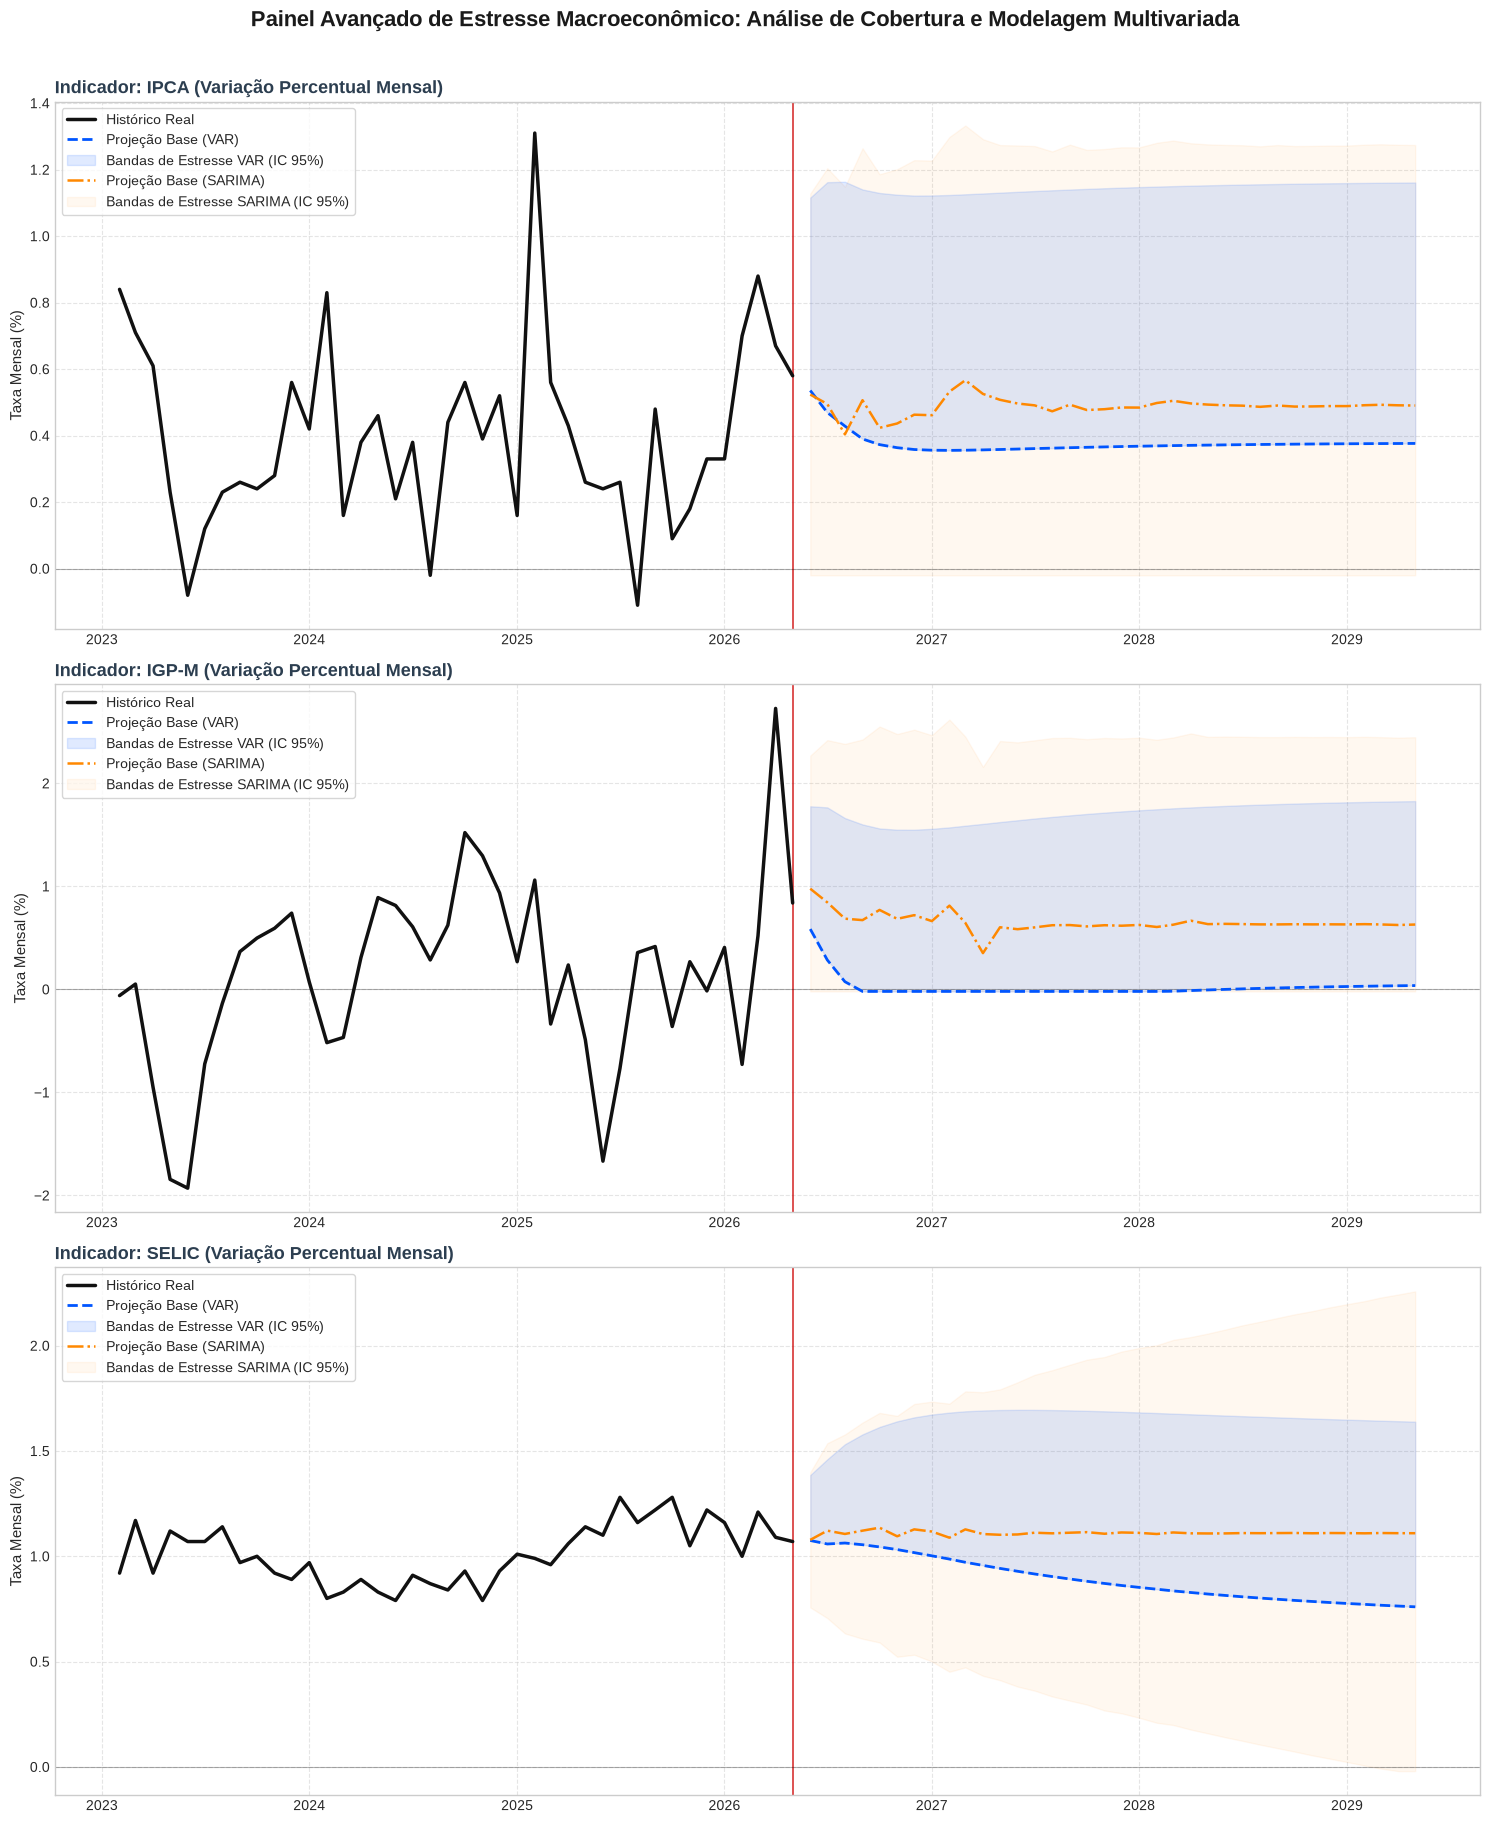

In [ ]:

colunas_treinadas_var = list(engine.model_fitted.names)

df_var_futuro_input = df_analise_corrigido[colunas_treinadas_var].astype(float)

cenarios_var_futuro = engine.gerar_projeções_estresse(df_var_futuro_input)

fig, axes = plt.subplots(3, 1, figsize=(15, 18), dpi=100)

for idx, (apelido, nome_coluna) in enumerate(alvos_grid.items()):
    ax = axes[idx]
    
    hist_plot = pd.to_numeric(df_analise_corrigido[nome_coluna].tail(40), errors='coerce').dropna().astype(float)
    
    df_var_f = cenarios_var_futuro[nome_coluna]
    var_b = pd.to_numeric(df_var_f["CENARIO_BASE"], errors='coerce').astype(float)
    var_s = pd.to_numeric(df_var_f["CENARIO_ESTRESSE_SUPERIOR"], errors='coerce').astype(float)
    var_i = pd.to_numeric(df_var_f["CENARIO_ESTRESSE_INFERIOR"], errors='coerce').astype(float)
    
    df_sarima_f = engine.gerar_projeções_benchmark_sarima(df_var_futuro_input[[nome_coluna]], coluna_alvo=nome_coluna)
    sar_b = pd.to_numeric(df_sarima_f["SARIMA_BASE"], errors='coerce').astype(float)
    sar_s = pd.to_numeric(df_sarima_f["SARIMA_ESTRESSE_SUPERIOR"], errors='coerce').astype(float)
    sar_i = pd.to_numeric(df_sarima_f["SARIMA_ESTRESSE_INFERIOR"], errors='coerce').astype(float)
    
    ax.plot(hist_plot.index, hist_plot.values, color="#111111", linewidth=2.5, label="Histórico Real", zorder=4)
    
    ax.plot(var_b.index, var_b.values, color="#0055ff", linestyle="--", linewidth=2, label="Projeção Base (VAR)", zorder=3)
    ax.fill_between(var_b.index, var_i.values, var_s.values, color="#0055ff", alpha=0.12, label="Bandas de Estresse VAR (IC 95%)", zorder=2)
    
    ax.plot(sar_b.index, sar_b.values, color="#ff8800", linestyle="-.", linewidth=1.8, label="Projeção Base (SARIMA)", zorder=3)
    ax.fill_between(sar_b.index, sar_i.values, sar_s.values, color="#ff8800", alpha=0.06, label="Bandas de Estresse SARIMA (IC 95%)", zorder=1)
    
    ax.axvline(x=hist_plot.index[-1], color="#cc0000", linestyle="-", linewidth=1.2, alpha=0.8)
    
    ax.set_title(f"Indicador: {apelido} (Variação Percentual Mensal)", fontsize=13, fontweight='bold', color='#2c3e50', loc='left')
    ax.set_ylabel("Taxa Mensal (%)", fontsize=11)
    ax.grid(True, linestyle="--", alpha=0.5, color="#cccccc")
    
    ax.axhline(0, color='black', linestyle='-', linewidth=0.8, alpha=0.3)
    ax.legend(loc="upper left", frameon=True, facecolor="white", fontsize=10)
    
    ax.relim()
    ax.autoscale_view()

plt.suptitle("Painel Avançado de Estresse Macroeconômico: Análise de Cobertura e Modelagem Multivariada", 
             fontsize=16, fontweight='bold', y=1.01, color='#1a1a1a')

plt.tight_layout()
plt.show()

🚀 Indicador_Customizado_Firma gerado com sucesso utilizando séries temporalmente padronizadas (Z-Score)!
Pesos aplicados sobre escala idêntica (Média=0, Var=1):
 -> 433 - Índice nacional de preços ao consumidor-amplo (IPCA) - Var. % mensal: 50.0%
 -> 4390 - Taxa de juros - Selic acumulada no mês - % a.m.: 30.0%
 -> Índice Geral de Preços - IGP-M(200045): 20.0%


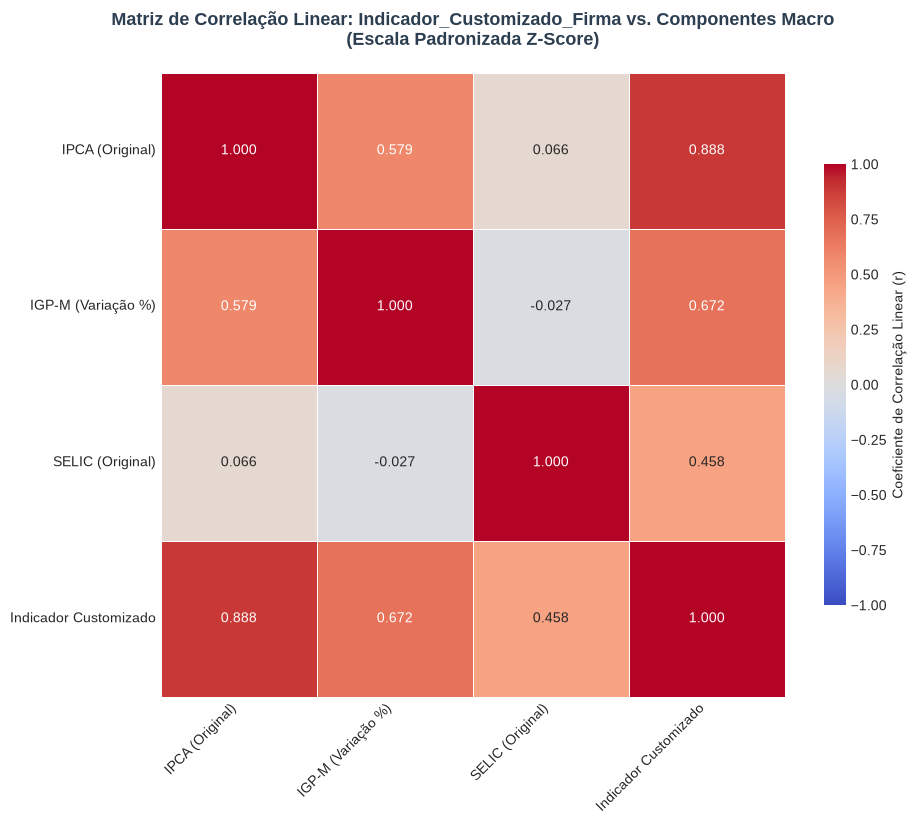


🔍 Executando Teste de Dickey-Fuller Aumentado (ADF) no Indicador Customizado Normalizado...
 -> Estatística ADF: -3.5106
 -> P-Valor: 0.0077
 -> Valores Críticos:
    1%: -3.4492
    5%: -2.8698
    10%: -2.5712
📌 CONCLUSÃO: A combinação linear normalizada é ESTACIONÁRIA (95% de confiança).


In [ ]:


# ==============================================================================
# 1. CONFIGURAÇÃO DO INDICADOR CUSTOMIZADO
# ==============================================================================
config_indicador_custom = {
    coluna_ipca: 0.50,
    coluna_selic: 0.30,
    coluna_igpm: 0.20
}

nome_custom = "Indicador_Customizado_Firma"

regras_normalizacao = {}
df_normalizado_temp = pd.DataFrame(index=df_analise_corrigido.index)

# --- NORMALIZAÇÃO VIA Z-SCORE (MÉDIA 0, VARIÂNCIA 1) ---
for col in config_indicador_custom.keys():
    s_original = pd.to_numeric(df_analise_corrigido[col], errors='coerce')
    mean_val = s_original.mean()
    std_val = s_original.std()
    

    regras_normalizacao[col] = {"media": mean_val, "desvio": std_val}
    
    df_normalizado_temp[col] = (s_original - mean_val) / std_val

df_analise_corrigido[nome_custom] = 0.0
for col, peso in config_indicador_custom.items():
    df_analise_corrigido[nome_custom] += df_normalizado_temp[col] * peso

print(f"🚀 {nome_custom} gerado com sucesso utilizando séries temporalmente padronizadas (Z-Score)!")
print("Pesos aplicados sobre escala idêntica (Média=0, Var=1):")
for k, v in config_indicador_custom.items():
    print(f" -> {k}: {v*100:.1f}%")

# ==============================================================================
# 2. CÓDIGO DA MATRIZ DE CORRELAÇÃO (CORRIGIDO PARA NOMES LONGOS)
# ==============================================================================
colunas_correlacao = [coluna_ipca, coluna_igpm, coluna_selic, nome_custom]

matriz_corr = df_analise_corrigido[colunas_correlacao].corr()

fig, ax = plt.subplots(figsize=(12, 10), dpi=100)

mapeamento_rotulos = {
    coluna_ipca: "IPCA (Original)",
    coluna_igpm: "IGP-M (Variação %)",
    coluna_selic: "SELIC (Original)",
    nome_custom: "Indicador Customizado"
}
matriz_corr_visual = matriz_corr.rename(index=mapeamento_rotulos, columns=mapeamento_rotulos)

sns.heatmap(
    matriz_corr_visual, 
    annot=True,              
    cmap="coolwarm",         
    fmt=".3f",               
    vmin=-1,                 
    vmax=1,                  
    square=True,             
    linewidths=0.5,          
    cbar_kws={
        'label': 'Coeficiente de Correlação Linear (r)',
        'shrink': 0.7        
    },
    ax=ax
)

plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(rotation=0, fontsize=10)

plt.title(f"Matriz de Correlação Linear: {nome_custom} vs. Componentes Macro\n(Escala Padronizada Z-Score)", 
          fontsize=13, fontweight='bold', pad=20, color='#2c3e50')

plt.subplots_adjust(left=0.25, bottom=0.25)

plt.show()

# ==============================================================================
# 3. TESTE DE ESTACIONARIEDADE (ADF TEST)
# ==============================================================================
print("\n🔍 Executando Teste de Dickey-Fuller Aumentado (ADF) no Indicador Customizado Normalizado...")
resultado_adf = adfuller(df_analise_corrigido[nome_custom].dropna())

print(f" -> Estatística ADF: {resultado_adf[0]:.4f}")
print(f" -> P-Valor: {resultado_adf[1]:.4f}")
print(" -> Valores Críticos:")
for chave, valor in resultado_adf[4].items():
    print(f"    {chave}: {valor:.4f}")

if resultado_adf[1] < 0.05:
    print("📌 CONCLUSÃO: A combinação linear normalizada é ESTACIONÁRIA (95% de confiança).")
else:
    print("📌 CONCLUSÃO: A série combinação NÃO É ESTACIONÁRIA.")

🎲 Iniciando Monte Carlo Estocástico Multivariado | N = 10000 | H = 36 meses

📊 --- RELATÓRIO QUANTÍTATIVO DE RISCO DE CAUDA (VaR ESTOCÁSTICO) ---


,Mediana (Cenário Base),Limite Inferior (Estresse 90%),Limite Superior (Estresse 90%),Limite Inferior (Estresse 95%),Limite Superior (Estresse 95%),Limite Inferior (Estresse 99%),Limite Superior (Estresse 99%)
Mês +1,1.842390,1.253546,2.437403,1.077154,2.604958,0.786778,2.937948
Mês +2,2.626201,1.891600,3.345362,1.684452,3.559128,1.310750,3.950028
Mês +3,3.574480,2.785715,4.350182,2.558213,4.583848,2.172799,4.983094
Mês +4,4.336904,3.537688,5.142168,3.309020,5.381248,2.894768,5.816198
Mês +5,5.028400,4.215300,5.849207,3.982848,6.082594,3.577006,6.520724
Mês +6,5.703904,4.872913,6.537542,4.625468,6.798429,4.195206,7.250694
Mês +7,6.329044,5.494054,7.178177,5.253670,7.404276,4.755611,7.850635
Mês +8,6.929707,6.088374,7.760447,5.863846,8.018128,5.406154,8.459620
Mês +9,7.477389,6.644578,8.307140,6.404285,8.562969,5.933280,9.022402
Mês +10,8.005173,7.173463,8.845590,6.918902,9.096433,6.445016,9.575821


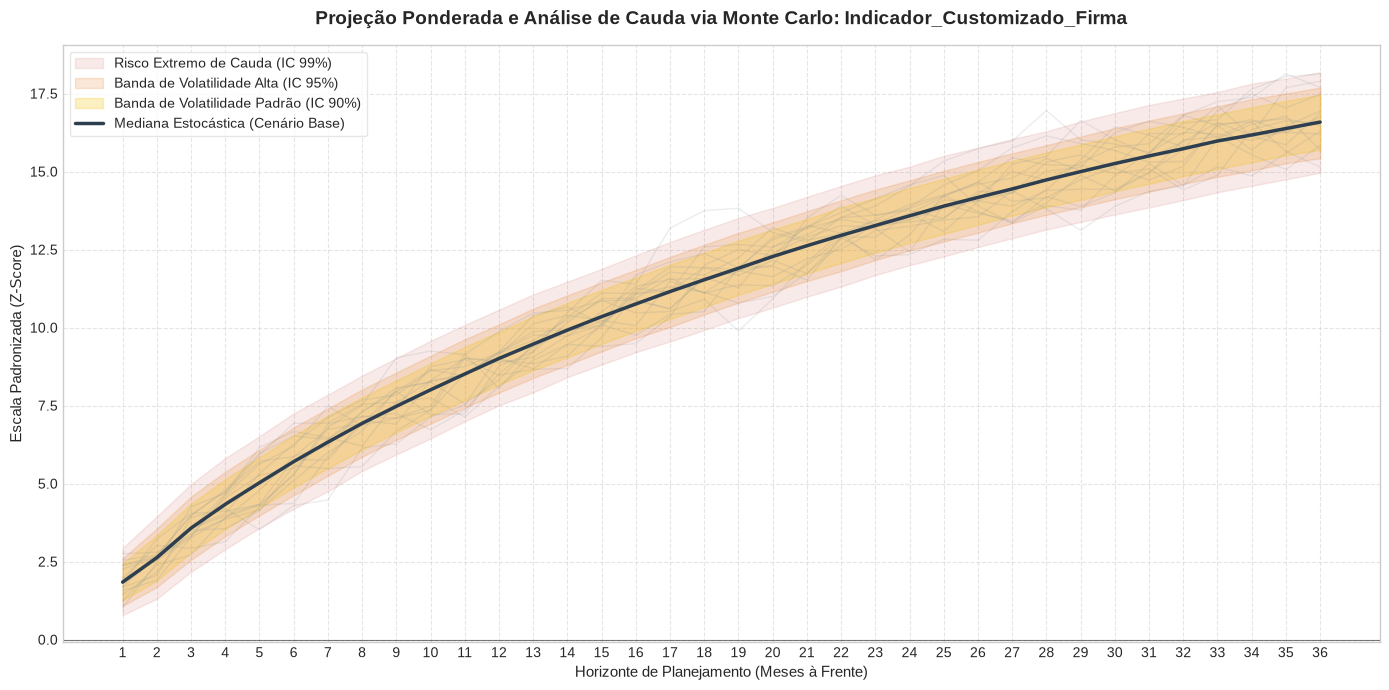

In [ ]:
simulador = MacroMonteCarloSimulator(
    engine=engine, 
    regras_normalizacao=regras_normalizacao, 
    config_indicador_custom=config_indicador_custom
)


trajetorias_macro = simulador.rodar_simulacao(df_analise_corrigido, n_simulacoes=10000)

trajetorias_portfolio = simulador.consolidar_indicador_customizado(trajetorias_macro)

df_var_estocastico = simulador.extrair_metricas_risco(trajetorias_portfolio)

print("\n📊 --- RELATÓRIO QUANTÍTATIVO DE RISCO DE CAUDA (VaR ESTOCÁSTICO) ---")
display(df_var_estocastico.head(12))

simulador.plotar_painel_mc(df_var_estocastico, trajetorias_portfolio, nome_indicador=nome_custom)

🎲 Iniciando Monte Carlo Estocástico Multivariado | N = 10000 | H = 36 meses

📊 --- RELATÓRIO QUANTITATIVO DE RISCO DE CAUDA INTEGRADO (MÊS +12) ---


,Tipo,Mediana,VaR 90% (Sup),VaR 95% (Sup),VaR 99% (Sup),Volatilidade Sim.
Indicador,,,,,,
433 - Índice nacional de preços ao consumidor-amplo (IPCA) - Var. % mensal,Original (Bruto),3.109231,3.617091,3.758048,4.032539,0.392335
3696 - Taxa de câmbio - Livre - Dólar americano (venda) - Fim de período - mensal - u.m.c./US$,Original (Bruto),13.406897,14.055427,14.238588,14.586639,0.506075
4390 - Taxa de juros - Selic acumulada no mês - % a.m.,Original (Bruto),9.386165,9.870034,10.006722,10.293285,0.383572
Índice Geral de Preços - IGP-M(200045),Original (Bruto),3.804904,4.932276,5.228775,5.833047,0.880477
IGP-M - Fechamento mensal (%)(1000367),Original (Bruto),3.799556,4.928400,5.226151,5.829683,0.880669
INCC-M - Fechamento mensal (%)(1000370),Original (Bruto),3.403813,4.062304,4.245895,4.577961,0.508692
IPA-M - Fechamento mensal (% mês) (1478707),Original (Bruto),4.593277,6.184090,6.605450,7.457218,1.240437
IPAEP-M Ipa - todos os itens - Nro. Índice(1473921),Original (Bruto),1414.539957,1492.966743,1514.364629,1554.414407,60.535101
IPC/BR-M - Fechamento Mensal - % (POF 2017/2018). Vigência a partir de 01/2020(1448925),Original (Bruto),3.057381,3.607800,3.760568,4.048776,0.424366


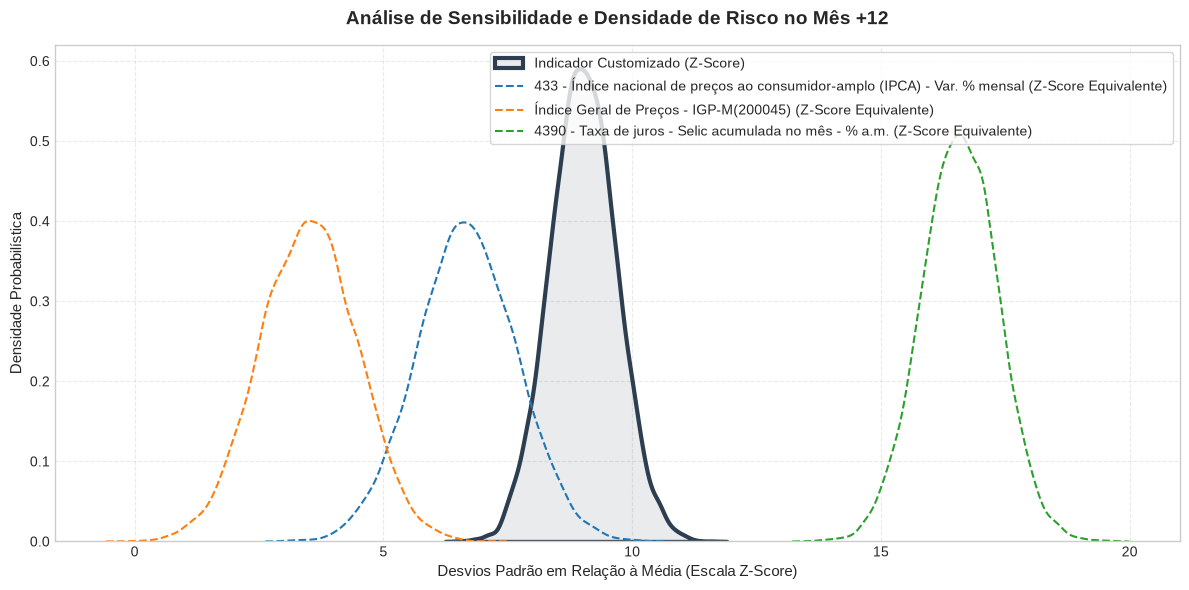


📈 Gerando painéis de volatilidade para os componentes individuais...


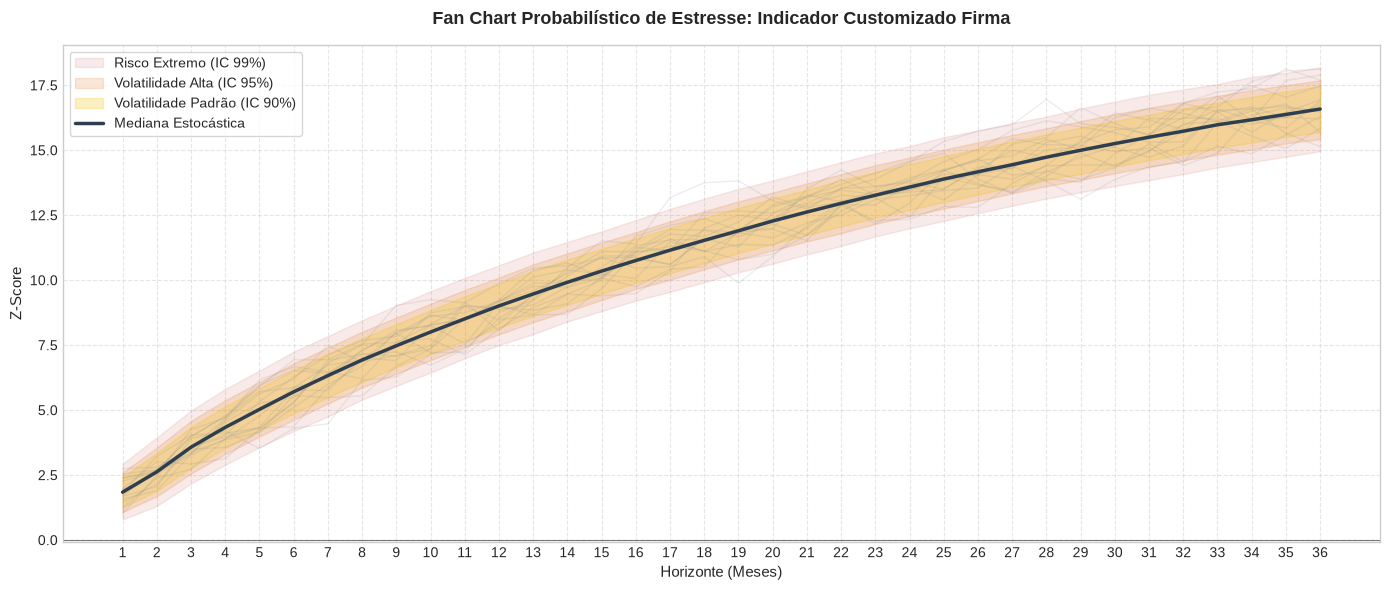

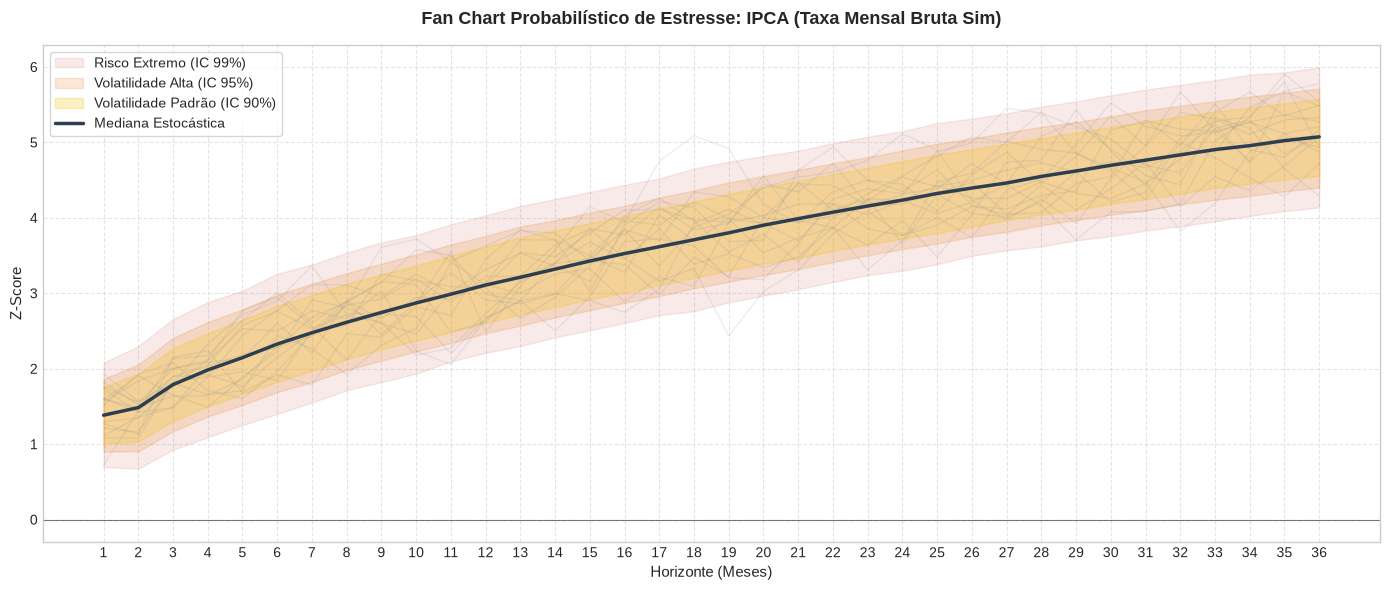

In [ ]:

simulador = MacroMonteCarloSimulator(
    engine=engine, 
    regras_normalizacao=regras_normalizacao, 
    config_indicador_custom=config_indicador_custom
)

trajetorias_macro = simulador.rodar_simulacao(df_analise_corrigido, n_simulacoes=10000)

trajetorias_portfolio = simulador.consolidar_indicador_customizado(trajetorias_macro)

# ==============================================================================
# ANÁLISE PROFUNDA 1: RELATÓRIO COMPARATIVO DE VAR (MÊS +12 - FIM DE UM ANO)
# ==============================================================================
print("\n📊 --- RELATÓRIO QUANTITATIVO DE RISCO DE CAUDA INTEGRADO (MÊS +12) ---")
df_comparativo_12m = simulador.gerar_relatorio_consolidado_var(trajetorias_macro, trajetorias_portfolio, mes_alvo=12)
display(df_comparativo_12m)

# ==============================================================================
# ANÁLISE PROFUNDA 2: MAPA DE DENSIDADE E ACHATAMENTO DE CAUDA (KURTOSIS VISUAL)
# ==============================================================================
colunas_foco_analise = [coluna_ipca, coluna_igpm, coluna_selic]
simulador.plotar_comparativo_distribuicoes(trajetorias_macro, trajetorias_portfolio, mes_alvo=12, colunas_foco=colunas_foco_analise)

# ==============================================================================
# ANÁLISE PROFUNDA 3: COMPARATIVO DE FAN CHARTS PARA AS VARIÁVEIS ORIGINAIS
# ==============================================================================
print("\n📈 Gerando painéis de volatilidade para os componentes individuais...")
df_metricas_custom = simulador.extrair_metricas_risco_serie(trajetorias_portfolio)
simulador.plotar_painel_mc(df_metricas_custom, trajetorias_portfolio, nome_indicador="Indicador Customizado Firma")

idx_ipca = simulador.names.index(coluna_ipca)
df_metricas_ipca = simulador.extrair_metricas_risco_serie(trajetorias_macro[:, :, idx_ipca])
simulador.plotar_painel_mc(df_metricas_ipca, trajetorias_macro[:, :, idx_ipca], nome_indicador="IPCA (Taxa Mensal Bruta Sim)")

📊 Processando matrizes de VaR Estocástico...
💾 Dados financeiros salvos em: ../outputs_relatorios/Relatorio_Capital_Risk_MonteCarlo.xlsx

🎨 Renderizando e exportando painéis visuais...
🖼️ Gráfico de densidade exportado com sucesso: ../outputs_relatorios/densidade_risco_mes_12.png


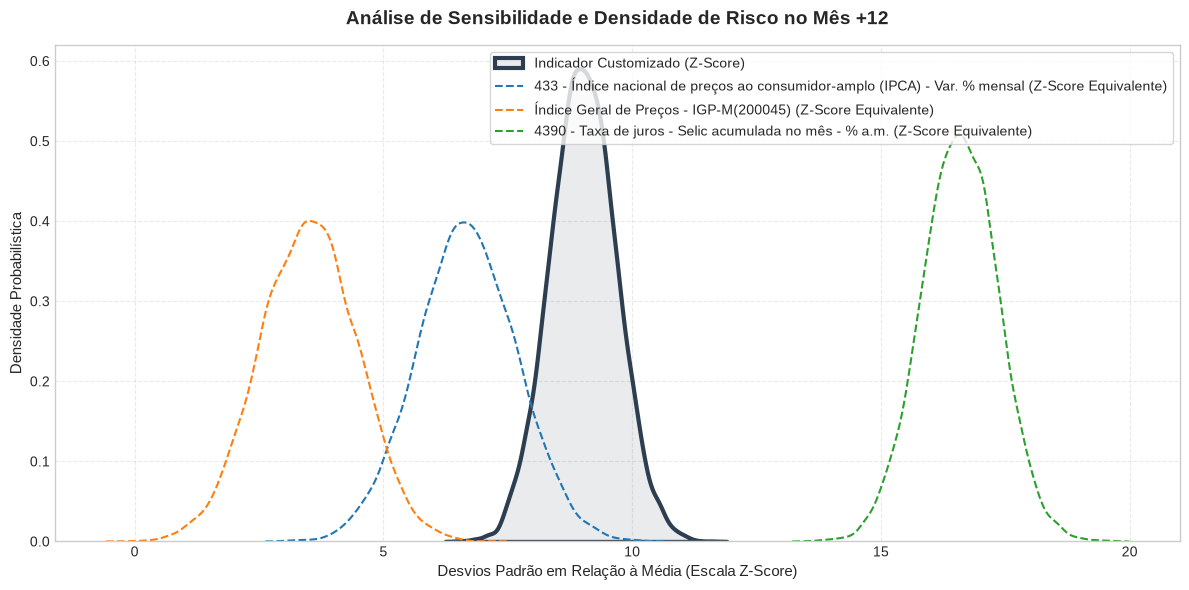

🖼️ Fan Chart exportado com sucesso: ../outputs_relatorios/fan_chart_indicador_customizado.png


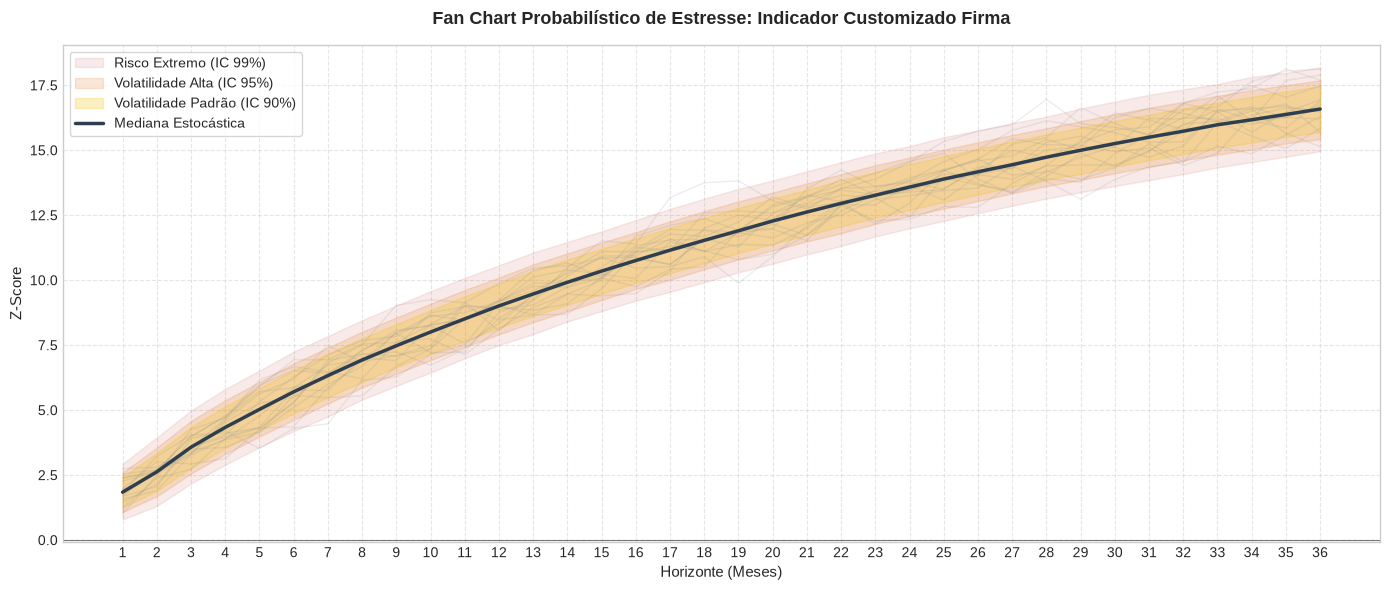

🖼️ Fan Chart exportado com sucesso: ../outputs_relatorios/fan_chart_ipca_bruto.png


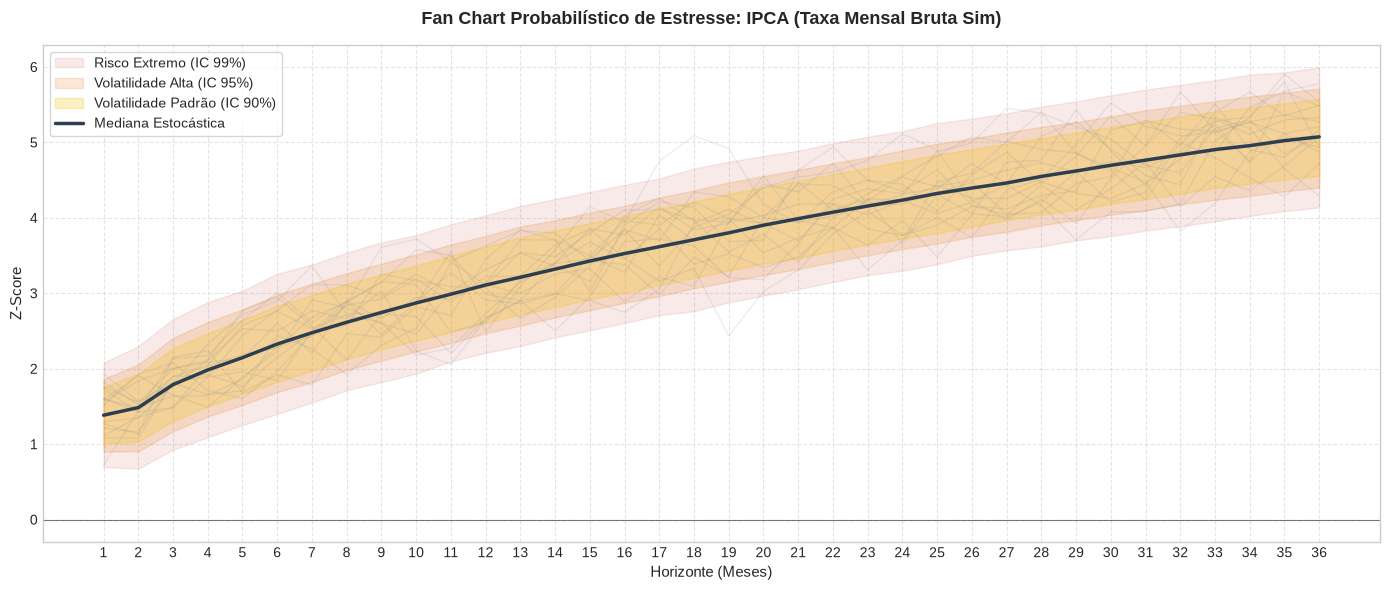


🤐 Compactando diretório para evitar erros de MIME Type no download...
⚡ Arquivo compactado gerado com sucesso: /home/marth/Documentos/caprisk-engine/notebooks/relatorios_monte_carlo.zip
🚀 Pipeline finalizado sem interrupções!


In [ ]:
simulador = MacroMonteCarloSimulator(engine, regras_normalizacao, config_indicador_custom)

diretorio_output = "../outputs_relatorios"
os.makedirs(diretorio_output, exist_ok=True)

# ------------------------------------------------------------------------------
#  GERAÇÃO E GRAVAÇÃO DAS PLANILHAS (EXCEL E CSV)
# ------------------------------------------------------------------------------
print("📊 Processando matrizes de VaR Estocástico...")
df_var_12m = simulador.gerar_relatorio_consolidado_var(trajetorias_macro, trajetorias_portfolio, mes_alvo=12)
df_var_24m = simulador.gerar_relatorio_consolidado_var(trajetorias_macro, trajetorias_portfolio, mes_alvo=24)
df_var_36m = simulador.gerar_relatorio_consolidado_var(trajetorias_macro, trajetorias_portfolio, mes_alvo=36)

df_var_12m.to_csv(os.path.join(diretorio_output, "var_estocastico_mes_12.csv"), encoding='utf-8-sig')

caminho_excel = os.path.join(diretorio_output, "Relatorio_Capital_Risk_MonteCarlo.xlsx")
with pd.ExcelWriter(caminho_excel, engine='openpyxl') as writer:
    df_var_12m.to_excel(writer, sheet_name="Horizonte 1 Ano (Mês +12)")
    df_var_24m.to_excel(writer, sheet_name="Horizonte 2 Anos (Mês +24)")
    df_var_36m.to_excel(writer, sheet_name="Horizonte 3 Anos (Mês +36)")
print(f"💾 Dados financeiros salvos em: {caminho_excel}")

# ------------------------------------------------------------------------------
#  GERAÇÃO E SALVAMENTO PREVENTIVO DOS GRÁFICOS (PNG)
# ------------------------------------------------------------------------------
print("\n🎨 Renderizando e exportando painéis visuais...")

# Gráfico 1: Densidade de Risco Comparada
path_img1 = os.path.join(diretorio_output, "densidade_risco_mes_12.png")
simulador.plotar_comparativo_distribuicoes(trajetorias_macro, trajetorias_portfolio, mes_alvo=12, 
                                           colunas_foco=colunas_foco_analise, caminho_salvar=path_img1)

# Gráfico 2: Fan Chart do Indicador Customizado
path_img2 = os.path.join(diretorio_output, "fan_chart_indicador_customizado.png")
simulador.plotar_painel_mc(df_metricas_custom, trajetorias_portfolio, 
                           nome_indicador="Indicador Customizado Firma", caminho_salvar=path_img2)

# Gráfico 3: Fan Chart do IPCA Bruto
path_img3 = os.path.join(diretorio_output, "fan_chart_ipca_bruto.png")
idx_ipca = simulador.names.index(coluna_ipca)
df_metricas_ipca = simulador.extrair_metricas_risco_serie(trajetorias_macro[:, :, idx_ipca])
simulador.plotar_painel_mc(df_metricas_ipca, trajetorias_macro[:, :, idx_ipca], 
                           nome_indicador="IPCA (Taxa Mensal Bruta Sim)", caminho_salvar=path_img3)

# ------------------------------------------------------------------------------
# ENVELOPE ZIP AUTOMÁTICO (SOLUÇÃO DE CONTORNO PARA ERRO DE DOWNLOAD)
# ------------------------------------------------------------------------------
print("\n🤐 Compactando diretório para evitar erros de MIME Type no download...")
caminho_zip = shutil.make_archive("relatorios_monte_carlo", 'zip', diretorio_output)
print(f"⚡ Arquivo compactado gerado com sucesso: {caminho_zip}")
print("🚀 Pipeline finalizado sem interrupções!")